<h1 align="center"> EDA </h1>

## **1. IMPORTING LIBRARIES**

In [ ]:
# Importing libraires
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
import plotly.express as px
import requests
import seaborn as sns

## **2. DATA LOADING**

Import the dataset r3_primarycare_opendata and store it as a Pandas DataFrame.

In [ ]:
# Data loading
df = pd.read_csv('https://raw.githubusercontent.com/DavidPF-Git/Allegheny-County.Primary-care-and-asthma-diagnosis-behavior-2016-2019/refs/heads/main/r3_primarycare_opendata.csv')

# Load the GeoJSON file for maps
geojson_url = "https://raw.githubusercontent.com/DavidPF-Git/Allegheny-County.Primary-care-and-asthma-diagnosis-behavior-2016-2019/refs/heads/main/tl_2025_42_bg_GEO.json"
response = requests.get(geojson_url)
geojson_data = response.json()

Check the dataset





In [ ]:
# Check the dataset
df.head()

,Geo_FIPS,StateFIPS,CountyFIPS,TractFIPS,BlockgroupFIPS,TotalPopEst2015_19ACS,Age0to17PopEst2015_19ACS,YearOfContactDate,AllPrimaryCarePatientsAge0to17,WellChildVisitsInPastYearAge0to17,WellChildVisitsInPastYearPer100PrimaryCarePatients,AsthmaDiagnosisAge0to17,AsthmaDiagnosisPer100PrimaryCarePatientsAge0to17
0,420031301002,42,3,130100,2,518,207,2016,82,59,72.0,17.0,20.7
1,420031301002,42,3,130100,2,518,207,2017,94,58,61.7,19.0,20.2
2,420031301002,42,3,130100,2,518,207,2018,89,63,70.8,19.0,21.3
3,420031301002,42,3,130100,2,518,207,2019,86,61,70.9,17.0,19.8
4,420031301003,42,3,130100,3,489,134,2016,53,34,64.2,18.0,34.0


## **3. NUMBER OF ROWS AND COLUMNS**

In [ ]:
# Number of rows and columns
print(f"Number of rows and columns: {df.shape}")

Number of rows and columns: (4366, 13)


The dataset contains 4366 observations and 13 variables.

## **4. VARIABLE DESCRIPTIONS**

This dataset provides information on primary care access and asthma prevalence among children (ages 0-17) at the census block group level in Allegheny County, Pensilvania.

* **Geo_FIPS**: Unique geographic identifier for the census block group.
* **StateFIPS**: Federal Information Processing Series (FIPS) code for Pennsylvania (42).
* **CountyFIPS**: FIPS code for Allegheny County (003).
* **TractFIPS**: FIPS code for the census tract.
* **BlockgroupFIPS**: Identifier for the census block group.
* **TotalPopEst2015_19ACS**: Total estimated population based on the American Community Survey (ACS) 2015-2019.
* **Age0to17PopEst2015_19ACS**: Estimated population of children and adolescents aged 0 to 17 years.
* **YearOfContactDate**: The calendar year in which the medical contact or data recording occurred (2016-2019).
* **AllPrimaryCarePatientsAge0to17**: Total count of unique patients (0-17 years old) who accessed primary care services.
* **WellChildVisitsInPastYearAge0to17**: Total number of preventive "well-child" visits recorded during the year for this age group.
* **WellChildVisitsInPastYearPer100PrimaryCarePatients**: Rate of preventive visits per 100 patients.
* **AsthmaDiagnosisAge0to17**: Number of pediatric patients diagnosed with asthma.
* **AsthmaDiagnosisPer100PrimaryCarePatientsAge0to17**: Asthma prevalence rate per 100 primary care patients.

## **5. CONCISE SUMMARY**

In [ ]:
# Concise summary
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4366 entries, 0 to 4365
Data columns (total 13 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Geo_FIPS                                            4366 non-null   int64  
 1   StateFIPS                                           4366 non-null   int64  
 2   CountyFIPS                                          4366 non-null   int64  
 3   TractFIPS                                           4366 non-null   int64  
 4   BlockgroupFIPS                                      4366 non-null   int64  
 5   TotalPopEst2015_19ACS                               4366 non-null   int64  
 6   Age0to17PopEst2015_19ACS                            4366 non-null   int64  
 7   YearOfContactDate                                   4366 non-null   int64  
 8   AllPrimaryCarePatientsAge0to17                      4366 non-null   int64  
 9

We observe 76 missing values in the AsthmaDiagnosisAge0to17 column, representing less than 2% of the dataset. Let’s examine these rows.

## **6. MISSING VALUES**

In [ ]:
# Missing values

# 1. Filter the rows where 'AsthmaDiagnosisAge0to17' is empty
missing_rows = df[df['AsthmaDiagnosisAge0to17'].isna()]

# 2. Display these specific rows
pd.set_option('display.max_rows', 100)
print(f"Number of rows found: {len(missing_rows)}")
missing_rows

Number of rows found: 76


,Geo_FIPS,StateFIPS,CountyFIPS,TractFIPS,BlockgroupFIPS,TotalPopEst2015_19ACS,Age0to17PopEst2015_19ACS,YearOfContactDate,AllPrimaryCarePatientsAge0to17,WellChildVisitsInPastYearAge0to17,WellChildVisitsInPastYearPer100PrimaryCarePatients,AsthmaDiagnosisAge0to17,AsthmaDiagnosisPer100PrimaryCarePatientsAge0to17
190,420030103002,42,3,10300,2,3419,33,2018,1,0,0.0,NaN,0.0
192,420030103003,42,3,10300,3,319,53,2017,6,6,100.0,NaN,0.0
193,420030103003,42,3,10300,3,319,53,2018,9,7,77.8,NaN,0.0
194,420030103003,42,3,10300,3,319,53,2019,9,7,77.8,NaN,0.0
212,420030201004,42,3,20100,4,965,25,2017,8,4,50.0,NaN,0.0
213,420030201004,42,3,20100,4,965,25,2018,12,9,75.0,NaN,0.0
214,420030201004,42,3,20100,4,965,25,2019,9,5,55.6,NaN,0.0
219,420030201006,42,3,20100,6,642,31,2016,15,12,80.0,NaN,0.0
220,420030201006,42,3,20100,6,642,31,2017,13,8,61.5,NaN,0.0
221,420030201006,42,3,20100,6,642,31,2018,8,8,100.0,NaN,0.0


We observe that all these rows have an asthma diagnosis rate of 0, which does not allow us to infer the missing values. It is also noted that these observations correspond to census blocks where a very low number of pediatric patients were treated. For this reason, and because the number of rows represents less than 2% of the total observations, we can replace the missing values with 0—assuming an insignificant number of cases were reported—without the risk of introducing bias.

In [ ]:
# Fill missing values

# 1. Fill missing values in 'AsthmaDiagnosisAge0to17' with 0
df['AsthmaDiagnosisAge0to17'] = df['AsthmaDiagnosisAge0to17'].fillna(0)

# 2. Verify that there are no more missing values
missing_after = df['AsthmaDiagnosisAge0to17'].isna().sum()
print(f"Missing values after cleaning: {missing_after}")

# 3. Check
df.info()

Missing values after cleaning: 0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4366 entries, 0 to 4365
Data columns (total 13 columns):
 #   Column                                              Non-Null Count  Dtype  
---  ------                                              --------------  -----  
 0   Geo_FIPS                                            4366 non-null   int64  
 1   StateFIPS                                           4366 non-null   int64  
 2   CountyFIPS                                          4366 non-null   int64  
 3   TractFIPS                                           4366 non-null   int64  
 4   BlockgroupFIPS                                      4366 non-null   int64  
 5   TotalPopEst2015_19ACS                               4366 non-null   int64  
 6   Age0to17PopEst2015_19ACS                            4366 non-null   int64  
 7   YearOfContactDate                                   4366 non-null   int64  
 8   AllPrimaryCarePatientsAge0to17               

## **7. IDENTIFICATION OF DUPLICATE RECORDS**

In [ ]:
# Identification of duplicate records
df.duplicated().sum()

np.int64(0)

There are no duplicate observations in the dataset.

## **8. IDENTIFYING UNIQUE VALUES**

In [ ]:
# Identifying unique values
for column in df.columns:
  print(f"{column}: {df[column].unique()} UNIQUE: {df[column].nunique()}")

Geo_FIPS: [420031301002 420031301003 420031302001 ... 420039812001 420039818001
 420039822001] UNIQUE: 1093
StateFIPS: [42] UNIQUE: 1
CountyFIPS: [3] UNIQUE: 1
TractFIPS: [130100 130200 130300 130400 130600 140100 140200 140300 140400 140500
 140600 140800 141000 141100 141300 141400 151600  10300  20100  20300
  30500  40200  40400  40500  40600  40900  50100  50600  50900  51000
  51100  60300  60500  70300  70500  70600  70800  70900  80200  80400
  80600  80700  80900  90100  90200  90300 100500 101100 101400 101600
 101700 101800 110200 110600 111300 111400 111500 120300 120400 120700
 120800 151700 160800 160900 170200 170600 180300 180700 190300 191100
 191400 191500 191600 191700 191800 191900 192000 202200 202300 210700
 220600 240600 241200 250300 250700 250900 260200 260700 260900 261200
 261400 261500 262000 270100 270300 270400 270800 271500 281400 281500
 290100 290200 290400 300100 310200 310300 320400 320600 320700 401100
 401200 401300 402000 403500 404000 405000 40600

## **9. SUMMARY OF DESCRIPTIVE STATISTICS**

In [ ]:
# Summary of descriptive statistics, location and year atributes not included
df.drop(df.columns[[0, 1, 2, 3, 4, 5, 7]], axis=1).describe()

,Age0to17PopEst2015_19ACS,AllPrimaryCarePatientsAge0to17,WellChildVisitsInPastYearAge0to17,WellChildVisitsInPastYearPer100PrimaryCarePatients,AsthmaDiagnosisAge0to17,AsthmaDiagnosisPer100PrimaryCarePatientsAge0to17
count,4366.000000,4366.000000,4366.000000,4366.000000,4366.000000,4366.000000
mean,210.364865,106.329134,88.224920,81.594297,16.590472,15.837334
std,176.048691,88.483753,77.075401,9.802341,13.727705,6.037080
min,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,96.000000,53.000000,42.000000,75.900000,8.000000,12.200000
50%,168.000000,85.000000,70.000000,82.700000,14.000000,15.400000
75%,270.750000,134.000000,109.000000,88.000000,22.000000,19.100000
max,1755.000000,1060.000000,924.000000,150.000000,151.000000,50.000000


## **10. TEMPORAL ANALYSIS**

### 10.1. COUNTY-WIDE TRENDS BY YEAR

In [ ]:
# County-wide trends by year

# 1. Use mean for rates and sum for absolute counts
yearly_trends = df.groupby('YearOfContactDate').agg({
    'AllPrimaryCarePatientsAge0to17': 'sum',
    'WellChildVisitsInPastYearAge0to17': 'sum',
    'AsthmaDiagnosisAge0to17': 'sum',
    'WellChildVisitsInPastYearPer100PrimaryCarePatients': 'mean',
    'AsthmaDiagnosisPer100PrimaryCarePatientsAge0to17': 'mean'
}).reset_index()

# 2. Display the aggregated table
print("Yearly Aggregated Data for Allegheny County:")
yearly_trends

Yearly Aggregated Data for Allegheny County:


,YearOfContactDate,AllPrimaryCarePatientsAge0to17,WellChildVisitsInPastYearAge0to17,AsthmaDiagnosisAge0to17,WellChildVisitsInPastYearPer100PrimaryCarePatients,AsthmaDiagnosisPer100PrimaryCarePatientsAge0to17
0,2016,112802,92313,18060.0,80.414299,16.326581
1,2017,114630,94775,18356.0,81.196242,16.283685
2,2018,118085,97724,18376.0,81.151235,15.697530
3,2019,118716,100378,17642.0,83.616224,15.041797


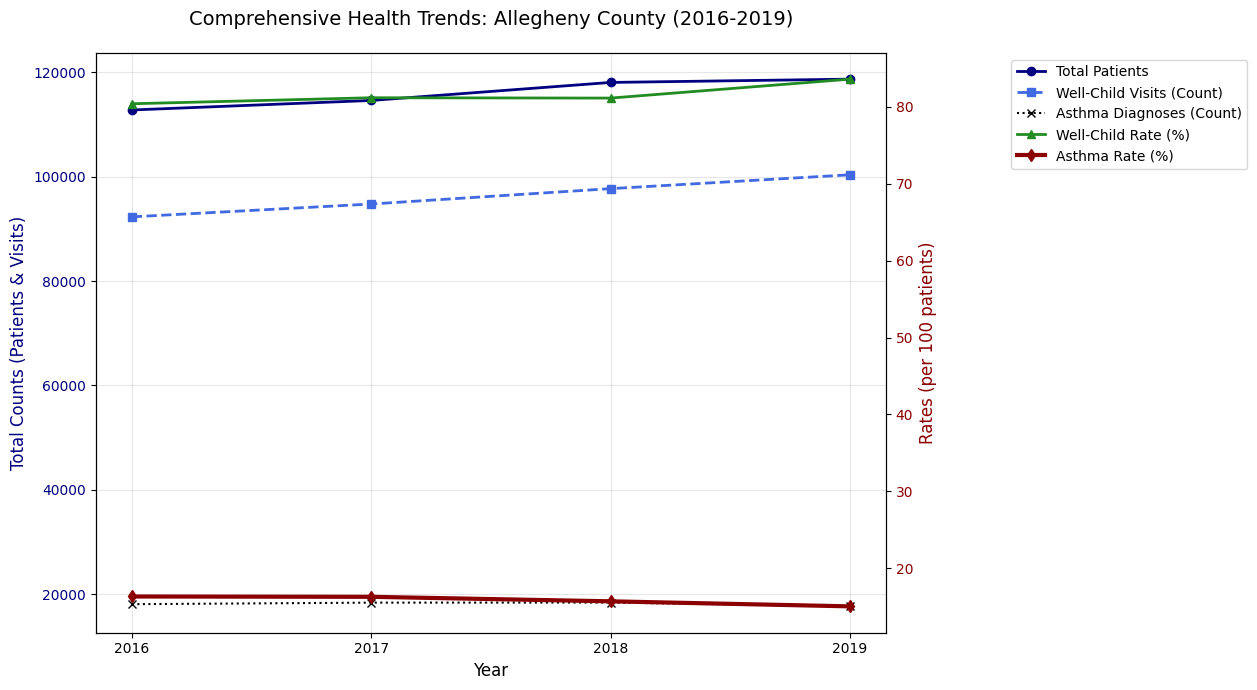

In [ ]:
# 1. Create the figure and the first axis (ax1) for absolute counts
fig, ax1 = plt.subplots(figsize=(13, 7))

# Plotting Absolute Counts (Left Axis - Volumes)
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Total Counts (Patients & Visits)', color='navy', fontsize=12)

# Total Patients
ax1.plot(yearly_trends['YearOfContactDate'], yearly_trends['AllPrimaryCarePatientsAge0to17'],
         marker='o', color='navy', linewidth=2, label='Total Patients')

# Well-Child Visits
ax1.plot(yearly_trends['YearOfContactDate'], yearly_trends['WellChildVisitsInPastYearAge0to17'],
         marker='s', color='royalblue', linewidth=2, linestyle='--', label='Well-Child Visits (Count)')

# Asthma Diagnoses (Count)
ax1.plot(yearly_trends['YearOfContactDate'], yearly_trends['AsthmaDiagnosisAge0to17'],
         marker='x', color='black', linewidth=1.5, linestyle=':', label='Asthma Diagnoses (Count)')

ax1.tick_params(axis='y', labelcolor='navy')
ax1.grid(True, alpha=0.3)

# 2. Create a second axis (ax2) for the rates (Percentages)
ax2 = ax1.twinx()

# Plotting Rates (Right Axis - Percentages)
ax2.set_ylabel('Rates (per 100 patients)', color='darkred', fontsize=12)

# Well-Child Rate
ax2.plot(yearly_trends['YearOfContactDate'], yearly_trends['WellChildVisitsInPastYearPer100PrimaryCarePatients'],
         marker='^', color='forestgreen', linewidth=2, label='Well-Child Rate (%)')

# Asthma Rate
ax2.plot(yearly_trends['YearOfContactDate'], yearly_trends['AsthmaDiagnosisPer100PrimaryCarePatientsAge0to17'],
         marker='d', color='darkred', linewidth=3, label='Asthma Rate (%)')

ax2.tick_params(axis='y', labelcolor='darkred')

# 3. Add title and format legends
plt.title('Comprehensive Health Trends: Allegheny County (2016-2019)', fontsize=14, pad=20)
plt.xticks(yearly_trends['YearOfContactDate'].astype(int))

# Combine legends from both axes into a single box
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left', bbox_to_anchor=(1.15, 1))

fig.tight_layout()
plt.show()

**1. Growth in Patient Coverage**

There is a steady increase in the total number of children served (`AllPrimaryCarePatientsAge0to17`) within the county.

* The count rose from **112,802** patients in 2016 to **118,716** in 2019.
* **Analysis:** The primary care system is reaching approximately **2,000 new children every year**, indicating either increased healthcare penetration or demographic growth within Allegheny County.



**2. Improvement in Preventive Medicine**

This is the most significant and positive trend observed in the dataset.

* The total volume of preventive visits (`WellChildVisitsInPastYearAge0to17`) jumped from **92,313** to **100,378**.
* The preventive visit rate increased from **80.4%** to **83.6%**.
* **Analysis:** Not only are there more patients, but a higher percentage of them are attending their annual check-ups. The year **2019** shows the most substantial leap in preventive effectiveness.



**3. Decline in Asthma Prevalence**

While the absolute number of children diagnosed with asthma remains relatively stable (around 18,000), the overall prevalence rate is decreasing.

* The diagnosis rate (`AsthmaDiagnosisPer100...`) dropped from **16.32%** in 2016 to **15.04%** in 2019.
* **Analysis:** This is a key clinical finding. As prevention efforts increase (well-child visits), the asthma diagnosis rate has fallen by nearly **1.3 percentage points** over the four-year period.

### 10.2. COVERAGE AND VOLUME ANALYSIS

Let’s look at the evolution of global primary care over time.

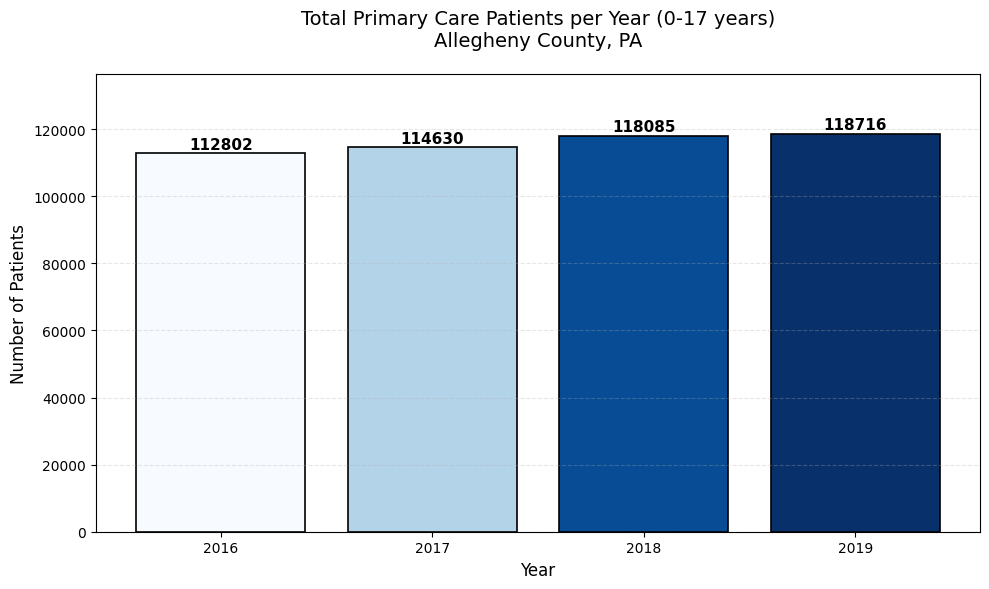

In [ ]:
# Coverage and volume analysis

# 1. Prepare data
years = yearly_trends['YearOfContactDate'].astype(int).astype(str)
patients = yearly_trends['AllPrimaryCarePatientsAge0to17']

# 2. Create a color map based on the values (Intensity proportional to value)
# Normalize the values to a range between 0 and 1 for the colormap
norm = plt.Normalize(patients.min(), patients.max())
colors = cm.Blues(norm(patients))

# 3. Create the plot
plt.figure(figsize=(10, 6))
bars = plt.bar(years, patients, color=colors, edgecolor='black', linewidth=1.2)

# 4. Add the values on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 500,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# 5. Styling and Labels
plt.title('Total Primary Care Patients per Year (0-17 years)\nAllegheny County, PA', fontsize=14, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Patients', fontsize=12)
plt.ylim(0, patients.max() * 1.15) # Leave some space for the labels
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Analysis of Pediatric Patient Coverage**

The data reveals a positive and steady upward trend in the number of children accessing primary care services in Allegheny County:

* **Continuous Growth:** The patient base expanded from **112802** in 2016 to **118716** in 2019, representing a total increase of **5.2%** (approximately 5914 additional patients) over the four-year period.
* **Year-over-Year Dynamics:** * The most significant surge occurred between **2017 and 2018**, with an addition of **3455** patients.
    * In contrast, the growth rate showed a slight **deceleration in 2019**, adding only **631** new patients compared to the previous year.
* **Conclusion:** This consistent growth suggests successful outreach and improved healthcare enrollment for the pediatric population, although the 2018-2019 plateau might indicate that the system is reaching a point of saturation or a stabilization in local demographics.

### 10.3. TREND OF WELL-CHILD PREVENTIVE VISIT COVERAGE

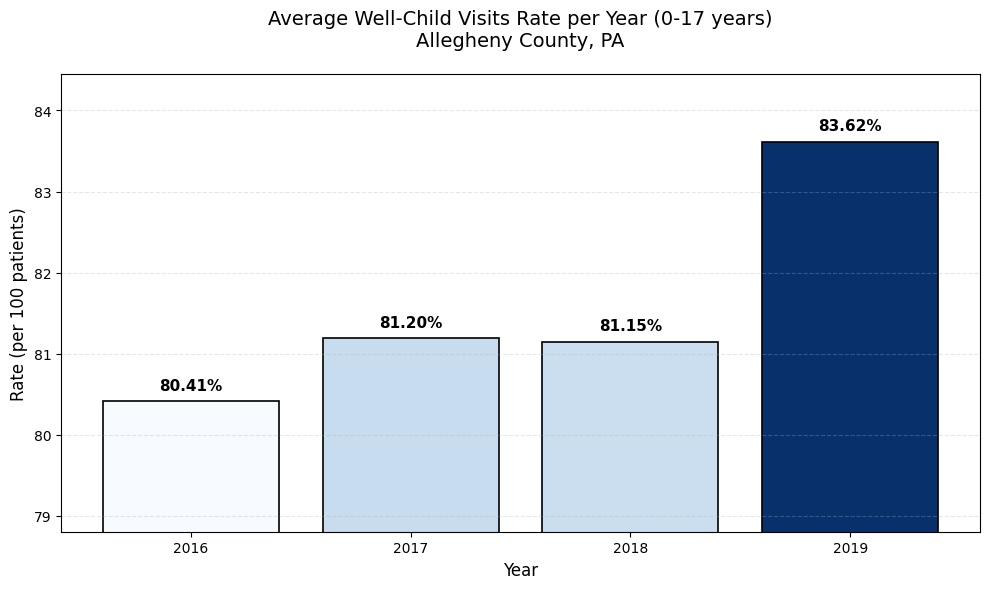

In [ ]:
# Trend of well-child preventive visit coverage

# 1. Prepare data (using the 'yearly_trends' DataFrame)
# Focus on the Rate per 100 patients as the primary preventive metric
years = yearly_trends['YearOfContactDate'].astype(int).astype(str)
preventive_rates = yearly_trends['WellChildVisitsInPastYearPer100PrimaryCarePatients']

# 2. Create a color map based on the values (Intensity proportional to value)
# Normalizing values for the colormap
norm = plt.Normalize(preventive_rates.min(), preventive_rates.max())
colors = cm.Blues(norm(preventive_rates))

# 3. Create the plot
plt.figure(figsize=(10, 6))
bars = plt.bar(years, preventive_rates, color=colors, edgecolor='black', linewidth=1.2)

# 4. Add the values on top of each bar (Rate with 2 decimal places)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.2f}%', # Formatting as percentage with 2 decimals
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# 5. Styling and Labels
plt.title('Average Well-Child Visits Rate per Year (0-17 years)\nAllegheny County, PA', fontsize=14, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Rate (per 100 patients)', fontsize=12)

# Set Y-axis limits with room for labels, starting near the minimum rate
plt.ylim(preventive_rates.min() * 0.98, preventive_rates.max() * 1.01)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Analysis of Preventive Care Trends (Well-Child Visits)**

The average rate of preventive visits per 100 patients shows a positive trajectory with a significant peak in the final year:

* **Overall Improvement:** The rate grew from **80.41%** in 2016 to **83.62%** in 2019. This indicates that by the end of the period, a higher proportion of the pediatric population was receiving essential preventive screenings.
* **The 2017-2018 Plateau:** Between 2017 (**81.20%**) and 2018 (**81.15%**), the rate remained virtually stagnant. This suggests that during these years, the increase in the number of patients was matched exactly by the increase in visits, maintaining the status quo in terms of coverage efficiency.
* **The 2019 Breakthrough:** A notable surge occurred in 2019, reaching **83.62%**. This represents the highest level of preventive engagement in the dataset and suggests that public health interventions or improved access protocols became particularly effective that year.
* **Conclusion:** The data reflects a high-performing primary care system in Allegheny County, where more than 8 out of 10 children consistently receive their annual well-child check-ups.

### 10.4. TREND OF ASTHMA PREVALENCE RATE

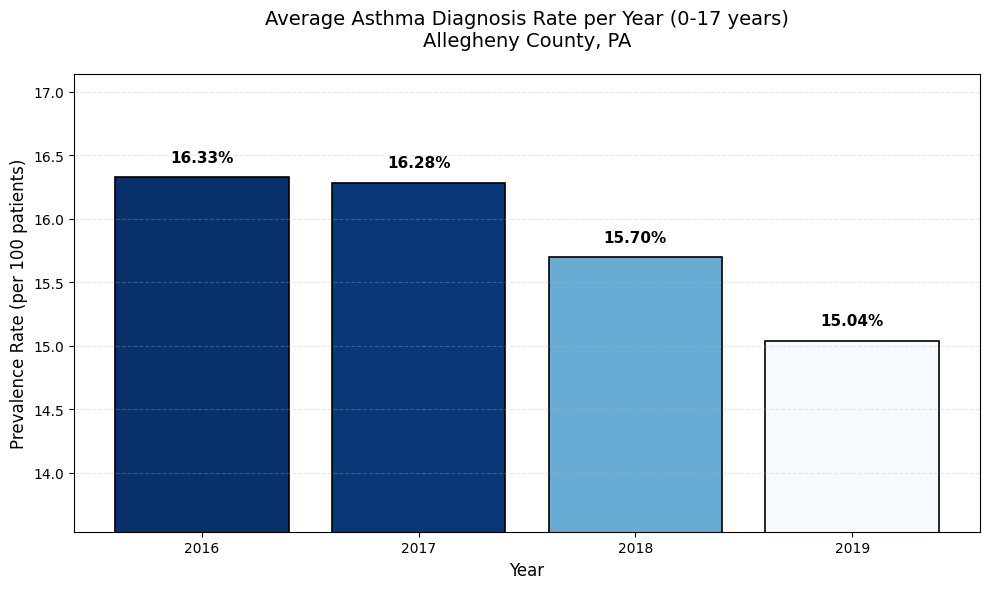

In [ ]:
# Trend of asthma prevalence rate

# 1. Prepare data
years = yearly_trends['YearOfContactDate'].astype(int).astype(str)
asthma_rates = yearly_trends['AsthmaDiagnosisPer100PrimaryCarePatientsAge0to17']

# 2. Create a color map based on the values (Intensity proportional to value)
# Normalizing values for the colormap
norm = plt.Normalize(asthma_rates.min(), asthma_rates.max())
colors = cm.Blues(norm(asthma_rates))

# 3. Create the plot
plt.figure(figsize=(10, 6))
bars = plt.bar(years, asthma_rates, color=colors, edgecolor='black', linewidth=1.2)

# 4. Add the values on top of each bar (Rate with 2 decimal places)
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.1,
             f'{height:.2f}%',
             ha='center', va='bottom', fontsize=11, fontweight='bold')

# 5. Styling and Labels
plt.title('Average Asthma Diagnosis Rate per Year (0-17 years)\nAllegheny County, PA', fontsize=14, pad=20)
plt.xlabel('Year', fontsize=12)
plt.ylabel('Prevalence Rate (per 100 patients)', fontsize=12)

# Set Y-axis limits (Starting a bit below the min to show the drop clearly)
plt.ylim(asthma_rates.min() * 0.9, asthma_rates.max() * 1.05)
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

**Analysis of Asthma Prevalence Trends**

The data shows a consistent and encouraging decline in the asthma diagnosis rate among the pediatric population in Allegheny County:

* **Steady Decline:** The prevalence rate dropped from **16.33%** in 2016 to **15.04%** in 2019. This represents a total reduction of **1.29 percentage points** over four years.
* **Accelerated Improvement:** While the decrease was marginal between 2016 and 2017 (-0.05 pts), the downward trend gained significant momentum after 2017, with the largest improvement occurring in the final year.
* **Clinical Significance:** A lower diagnosis rate in a growing patient population (as seen in Point 2) suggests that environmental factors or better early-stage management (potentially linked to the increase in preventive visits) might be positively impacting respiratory health.
* **Conclusion:** By 2019, Allegheny County achieved its lowest recorded asthma prevalence in this period, marking a clear success in pediatric health outcomes.

### 10.5. TEMPORAL CORRELATION ANALYSIS (PREVENTION/ASTHMA PREVALENCE)

By overlaying the **Well-Child Visit Rate** and the **Asthma Prevalence Rate**, we aim to identify potential correlations between preventive care and health outcomes.

* **Hypothesis:** An increase in routine pediatric check-ups (prevention) leads to better management of respiratory conditions, resulting in a decrease in overall asthma prevalence over time.
* **Visual Evidence:** The dual-axis chart allows us to observe if the record-high preventive rate in 2019 (**83.62%**) directly aligns with the record-low asthma rate (**15.04%**), suggesting a highly effective year for the county's healthcare strategy.

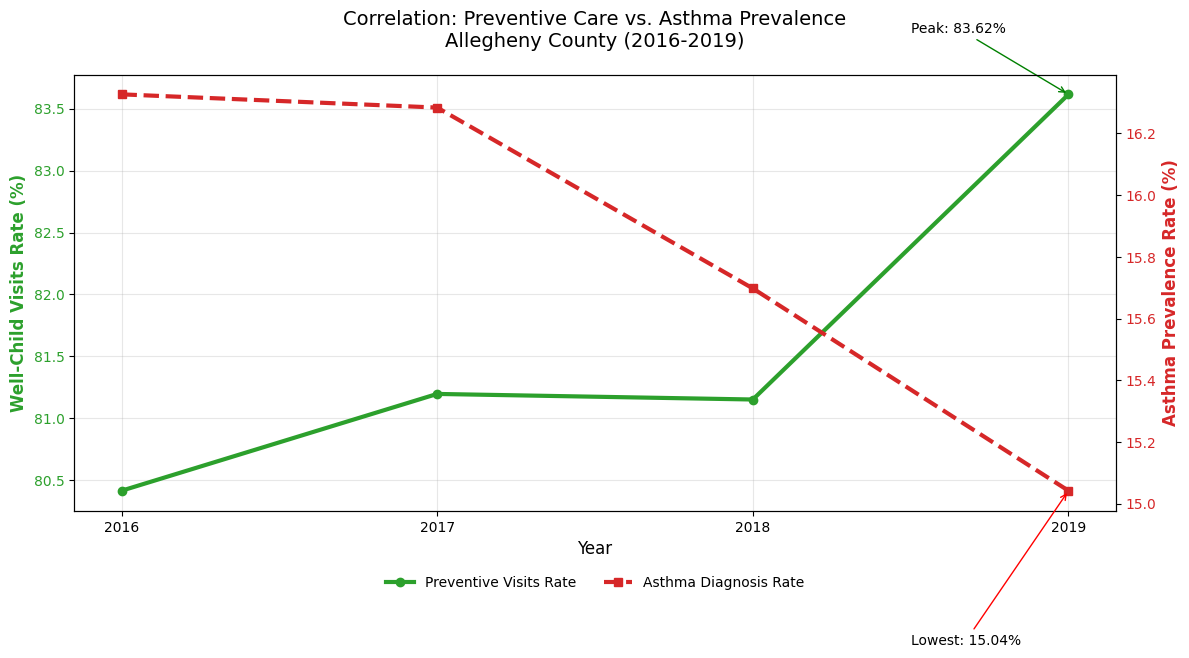

In [ ]:
# Temporal correlation analysis

# 1. Prepare the data
years = yearly_trends['YearOfContactDate'].astype(int)
prev_rate = yearly_trends['WellChildVisitsInPastYearPer100PrimaryCarePatients']
asthma_rate = yearly_trends['AsthmaDiagnosisPer100PrimaryCarePatientsAge0to17']

# 2. Create the figure and the first axis (ax1) for Prevention
fig, ax1 = plt.subplots(figsize=(12, 7))

color_prev = 'tab:green'
ax1.set_xlabel('Year', fontsize=12)
ax1.set_ylabel('Well-Child Visits Rate (%)', color=color_prev, fontsize=12, fontweight='bold')
line1 = ax1.plot(years, prev_rate, marker='o', color=color_prev, linewidth=3, label='Preventive Visits Rate')
ax1.tick_params(axis='y', labelcolor=color_prev)
ax1.grid(True, alpha=0.3)

# 3. Create the second axis (ax2) for Asthma
ax2 = ax1.twinx()

color_asthma = 'tab:red'
ax2.set_ylabel('Asthma Prevalence Rate (%)', color=color_asthma, fontsize=12, fontweight='bold')
line2 = ax2.plot(years, asthma_rate, marker='s', color=color_asthma, linewidth=3, linestyle='--', label='Asthma Diagnosis Rate')
ax2.tick_params(axis='y', labelcolor=color_asthma)

# 4. Title and aesthetics
plt.title('Correlation: Preventive Care vs. Asthma Prevalence\nAllegheny County (2016-2019)', fontsize=14, pad=20)
plt.xticks(years)

# Combine legends from both axes
lines = line1 + line2
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=2, frameon=False)

# 5. Add annotations for the "2019 Breakthrough"
ax1.annotate(f'Peak: {prev_rate.max():.2f}%',
             xy=(2019, prev_rate.max()), xytext=(2018.5, prev_rate.max()+0.5),
             arrowprops=dict(arrowstyle='->', color='green'))

ax2.annotate(f'Lowest: {asthma_rate.min():.2f}%',
             xy=(2019, asthma_rate.min()), xytext=(2018.5, asthma_rate.min()-0.5),
             arrowprops=dict(arrowstyle='->', color='red'))

fig.tight_layout()
plt.show()

**Temporal Correlation: Prevention vs. Outcomes**

The dual-axis chart reveals a compelling **inverse correlation** between preventive healthcare and asthma prevalence in Allegheny County:

* **The "Scissors" Effect:** As the green line (Preventive Visits) trends upward, the red dashed line (Asthma Rate) trends downward. This visual divergence is a strong indicator of a healthy public health ecosystem.
* **Key Milestone (2019):** The year 2019 represents the most successful period in the dataset. We observe the **highest rate of preventive care (83.62%)** coinciding with the **lowest rate of asthma diagnoses (15.04%)**.
* **Interpretation:** While correlation does not strictly imply causation, the data suggests that increased engagement in well-child visits may be contributing to better respiratory health management, earlier interventions, or more effective environmental education for families.
* **Final Conclusion:** The healthcare strategy in Allegheny County from 2016 to 2019 has been effective in simultaneously expanding patient coverage and improving specific health outcomes.

## **11. SPATIOTEMPORAL EVOLUTIONS**

### 11.1. PRIMARY CARE SPATIOTEMPORAL EVOLUTION

We will now generate an animated map to visualize the geographical evolution of Primary Care services over the study period.

In [ ]:
# Primary Care Spatiotemporal evolution

# 1. Data Preparation: Standardizing IDs
# We convert int64 to string and use zfill(12) to ensure it matches the GeoJSON GEOID
df['Geo_FIPS_str'] = df['Geo_FIPS'].astype(str).str.replace('.0', '', regex=False).str.zfill(12)

# 2. Define the Color Range
min_val = df['AllPrimaryCarePatientsAge0to17'].min()
max_val = df['AllPrimaryCarePatientsAge0to17'].max()

# 3. Create the Animated Choropleth Map
fig = px.choropleth_mapbox(
    df,
    geojson=geojson_data,
    locations='Geo_FIPS_str',       # Column in our DataFrame
    featureidkey="properties.GEOID",  # Path to the ID inside the GeoJSON
    color='AllPrimaryCarePatientsAge0to17',
    color_continuous_scale="Blues",
    range_color=[min_val, max_val],  # Fixed range for the animation
    animation_frame='YearOfContactDate',
    mapbox_style="carto-positron",
    zoom=9,
    center={"lat": 40.4406, "lon": -79.9959},
    opacity=0.7,
    labels={'AllPrimaryCarePatientsAge0to17': 'Total Patients'}
)

# 4. Layout and Animation Speed Adjustments
fig.update_layout(
    height=650,
    margin={"r":0,"t":50,"l":0,"b":0},
    title={
        'text': 'Spatiotemporal Evolution of Pediatric Primary Care Patients',
        'x': 0.5,
        'xanchor': 'center'},
    coloraxis_colorbar=dict(title="Patients")
)
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 800 # Time per year in ms

fig.show()

Output hidden; open in https://colab.research.google.com to view.

Let´s examine the table showing the top 5 tracks by greatest and least increments:

In [ ]:
# Top 5 tracks by greatest and least increments

# 1. Pivot the data to have years as columns for easy calculation
pivot_df = df.pivot(index='Geo_FIPS', columns='YearOfContactDate', values='AllPrimaryCarePatientsAge0to17')

# 2. Calculate the Delta (Absolute Change between 2019 and 2016)
pivot_df['Delta_Absolute'] = pivot_df[2019] - pivot_df[2016]

# 3. Calculate the Percentage Growth
pivot_df['Growth_Rate_Pct'] = (pivot_df['Delta_Absolute'] / pivot_df[2016]) * 100

# 4. Identify the Top 5 Tracks with the Highest Increase
top_5_growth = pivot_df.sort_values(by='Delta_Absolute', ascending=False).head(5)

# 5. Identify the Top 5 Tracks with the Lowest Increase (or Highest Decrease)
bottom_5_growth = pivot_df.sort_values(by='Delta_Absolute', ascending=True).head(5)

# --- Display Results ---

print("--- TOP 5: Highest Growth in Primary Care Patients (2016-2019) ---")
print(top_5_growth[[2016, 2019, 'Delta_Absolute', 'Growth_Rate_Pct']])

print("\n--- BOTTOM 5: Highest Decrease/Lowest Growth in Primary Care Patients (2016-2019) ---")
print(bottom_5_growth[[2016, 2019, 'Delta_Absolute', 'Growth_Rate_Pct']])

--- TOP 5: Highest Growth in Primary Care Patients (2016-2019) ---
YearOfContactDate   2016   2019  Delta_Absolute  Growth_Rate_Pct
Geo_FIPS                                                        
420034560012       279.0  420.0           141.0        50.537634
420034560033       300.0  418.0           118.0        39.333333
420034110001       315.0  416.0           101.0        32.063492
420034736022       165.0  245.0            80.0        48.484848
420034560032       218.0  298.0            80.0        36.697248

--- BOTTOM 5: Highest Decrease/Lowest Growth in Primary Care Patients (2016-2019) ---
YearOfContactDate   2016   2019  Delta_Absolute  Growth_Rate_Pct
Geo_FIPS                                                        
420034142001       473.0  402.0           -71.0       -15.010571
420034220001       346.0  282.0           -64.0       -18.497110
420034150013       448.0  388.0           -60.0       -13.392857
420034220002       185.0  140.0           -45.0       -24.324324
4

**Analysis of Geographic Extremes in Primary Care Enrollment (2016-2019)**

The tables identify the census block groups with the most significant shifts in the number of pediatric patients assigned to primary care services. This "Delta" (2019 vs. 2016) allows us to pinpoint where healthcare coverage is expanding most rapidly and where it is contracting.

**A. Top 5: Areas of Highest Growth**<br>
The areas with the most significant increases show a remarkable expansion of the patient base, with growth rates exceeding **30% to 50%**.
* **Leading Sector (ID: 420034560012):** This area saw the largest absolute increase, adding **141 patients**, a **50.5% growth** in just four years.
* **Consistency in High Growth:** Several sectors (e.g., ID: 4560033 and 4736022) show nearly 40-50% growth, suggesting either a successful healthcare outreach program in these neighborhoods or a significant influx of young families.

**B. Bottom 5: Areas of Highest Decrease**<br>
Conversely, some sectors have seen a notable reduction in the number of primary care patients.
* **Major Declines:** The sharpest drop occurred in sector **420034142001**, losing **71 patients (-15%)**.
* **Highest Percentage Drop:** Sector **420034220002** experienced the most severe relative decline, with a **24.3% reduction** in its pediatric patient population.
* **Potential Drivers:** These decreases might reflect local demographic shifts (such as families moving out of specific urban blocks) or potential barriers to healthcare access that might be causing patients to leave the primary care system in those specific zones.

**Key Insight**<br>
While the county-wide average shows a steady increase in primary care visits, these results prove that the **growth is not uniform**. The healthcare system is expanding aggressively in certain "hotspots" (specifically within the 456000 range of tracts) while receding in others, highlighting the importance of hyper-local geographic analysis for resource allocation.

### 11.2. WELL CHILD VISITS RATE SPATIOTEMPORAL EVOLUTION

We will now generate an animated map to visualize the geographical evolution of Well Child Visits Rate services over the study period.

In [ ]:
# Well Child Visits Rate Spatiotemporal Evolution

# 1. Define the Color Range
min_val = df['WellChildVisitsInPastYearPer100PrimaryCarePatients'].min()
max_val = df['WellChildVisitsInPastYearPer100PrimaryCarePatients'].max()

# 2. Create the Animated Choropleth Map
fig = px.choropleth_mapbox(
    df,
    geojson=geojson_data,
    locations='Geo_FIPS_str',       # Column in our DataFrame
    featureidkey="properties.GEOID",  # Path to the ID inside the GeoJSON
    color='WellChildVisitsInPastYearPer100PrimaryCarePatients',
    color_continuous_scale="Blues",
    range_color=[min_val, max_val],  # Fixed range for the animation
    animation_frame='YearOfContactDate',
    mapbox_style="carto-positron",
    zoom=9,
    center={"lat": 40.4406, "lon": -79.9959},
    opacity=0.7,
    labels={'WellChildVisitsInPastYearPer100PrimaryCarePatients': 'Rate'}
)

# 3. Layout and Animation Speed Adjustments
fig.update_layout(
    height=650,
    margin={"r":0,"t":50,"l":0,"b":0},
    title={
        'text': 'Spatiotemporal Evolution of Well Child Visits Rate',
        'x': 0.5,
        'xanchor': 'center'},
    coloraxis_colorbar=dict(title="Rate")
)
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 800 # Time per year in ms

fig.show()

Output hidden; open in https://colab.research.google.com to view.

Let´s examine the table showing the top 5 tracks by greatest and least increments:

In [ ]:
# Top 5 tracks by greatest and least increments

# 1. Pivot the data for Well-Child Visit Rates
wcv_pivot = df.pivot(index='Geo_FIPS', columns='YearOfContactDate', values='WellChildVisitsInPastYearPer100PrimaryCarePatients')

# 2. Calculate the Absolute Delta (2019 - 2016)
wcv_pivot['Delta_Absolute'] = wcv_pivot[2019] - wcv_pivot[2016]

# 3. Calculate Percentage Change
wcv_pivot['Change_Pct'] = (wcv_pivot['Delta_Absolute'] / wcv_pivot[2016]) * 100

# 4. Identify the Top 5 Tracks with the HIGHEST INCREASE (Positive Trend)
top_5_wcv_increase = wcv_pivot.sort_values(by='Delta_Absolute', ascending=False).head(5)

# 5. Identify the Top 5 Tracks with the HIGHEST DECREASE (Negative Trend)
top_5_wcv_decrease = wcv_pivot.sort_values(by='Delta_Absolute', ascending=True).head(5)

# --- Display Results ---
print("--- TOP 5: Highest Increase in Well-Child Visit Rates (Improving) ---")
print(top_5_wcv_increase[[2016, 2019, 'Delta_Absolute', 'Change_Pct']])

print("\n--- TOP 5: Highest Decrease in Well-Child Visit Rates (Worsening) ---")
print(top_5_wcv_decrease[[2016, 2019, 'Delta_Absolute', 'Change_Pct']])

--- TOP 5: Highest Increase in Well-Child Visit Rates (Improving) ---
YearOfContactDate  2016   2019  Delta_Absolute  Change_Pct
Geo_FIPS                                                  
420030201003       50.0  100.0            50.0  100.000000
420030406001       77.8  115.4            37.6   48.329049
420030705002       81.3  118.8            37.5   46.125461
420035632001       66.7  100.0            33.3   49.925037
420031706001       66.7  100.0            33.3   49.925037

--- TOP 5: Highest Decrease in Well-Child Visit Rates (Worsening) ---
YearOfContactDate  2016  2019  Delta_Absolute  Change_Pct
Geo_FIPS                                                 
420034643003       90.9  50.0           -40.9  -44.994499
420030405001       66.7  33.3           -33.4  -50.074963
420034688001       72.7  40.0           -32.7  -44.979367
420039822001       81.3  50.0           -31.3  -38.499385
420035642001       90.9  64.7           -26.2  -28.822882


**Statistical Analysis of Well-Child Visit (WCV) Rates (2016–2019)**

This section identifies the census block groups with the most significant shifts in preventive pediatric care compliance. The Well-Child Visit rate is a critical indicator of healthcare accessibility and the effectiveness of routine medical oversight for the pediatric population.

**A. Highest Increase in Well-Child Visit Rates (Improving Trends)**<br>
The "Top 5" growing sectors represent areas where preventive care has been successfully prioritized or expanded.

* **Exceptional Growth (ID: 420030201003):** This sector shows the most dramatic improvement in the county, with a **$50.0$ percentage point increase**, effectively doubling its 2016 rate to reach **$100\%$** compliance by 2019.
* **Full Coverage Achievement:** Several sectors, including **420035632001** and **420031706001**, reached a perfect **$100\%$** visit rate, indicating that every child in the primary care registry for those areas received their scheduled preventive checkups.
* **Rates Exceeding 100% (IDs: 0406001 & 0705002):** The presence of rates such as **$115.4\%$** and **$118.8\%$** suggests high clinical intensity. In small-area analysis, this often occurs when new patients enter the system mid-year or when outreach programs successfully capture mobile populations not initially accounted for in the baseline denominator.

**B. Highest Decrease in Well-Child Visit Rates (Worsening Trends)**<br>
Conversely, these sectors highlight a significant decline in preventive health engagement, indicating potential barriers to care.

* **Severe Attrition (ID: 420034643003):** This block group experienced the sharpest decline in the county, with a loss of **$40.9$ percentage points**, falling from near-total compliance ($90.9\%$) to only **$50\%$** in just four years.
* **Critical Drops (ID: 0405001):** This sector saw its preventive care participation cut exactly in half, dropping from **$66.7\%$** to **$33.3\%$** (a **$-50.07\%$** relative change).
* **Systemic Vulnerability:** Most sectors in the "Worsening" list saw relative declines of **$30\%$ to $45\%$**. Such drastic shifts in a short period usually point to systemic issues, such as the closure of a local pediatric clinic, transport difficulties, or significant socioeconomic changes within the neighborhood.

**Summary of Findings**<br>
The data reveals a starkly divided landscape. While some neighborhoods have reached total coverage for preventive visits, others have seen their safety net collapse by nearly half. These "Worsening" sectors should be considered high-priority areas for public health outreach, as the lack of routine checkups often leads to delayed immunizations and late-stage diagnoses of manageable conditions.

### 11.3. ASTHMA DIAGNOSIS RATE SPATIOTEMPORAL EVOLUTION

We will now generate an animated map to visualize the geographical evolution of Asthma Diagnosis over the study period.

In [ ]:
# Asthma Diagnosis Rate Spatiotemporal Evolution

# 1. Define the Color Range
min_val = df['AsthmaDiagnosisPer100PrimaryCarePatientsAge0to17'].min()
max_val = df['AsthmaDiagnosisPer100PrimaryCarePatientsAge0to17'].max()

# 2. Create the Animated Choropleth Map
fig = px.choropleth_mapbox(
    df,
    geojson=geojson_data,
    locations='Geo_FIPS_str',       # Column in our DataFrame
    featureidkey="properties.GEOID",  # Path to the ID inside the GeoJSON
    color='AsthmaDiagnosisPer100PrimaryCarePatientsAge0to17',
    color_continuous_scale="Blues",
    range_color=[min_val, max_val],  # Fixed range for the animation
    animation_frame='YearOfContactDate',
    mapbox_style="carto-positron",
    zoom=9,
    center={"lat": 40.4406, "lon": -79.9959},
    opacity=0.7,
    labels={'AsthmaDiagnosisPer100PrimaryCarePatientsAge0to17': 'Rate'}
)

# 3. Layout and Animation Speed Adjustments
fig.update_layout(
    height=650,
    margin={"r":0,"t":50,"l":0,"b":0},
    title={
        'text': 'Spatiotemporal Evolution of Asthma Diagnosis Rate',
        'x': 0.5,
        'xanchor': 'center'},
    coloraxis_colorbar=dict(title="Rate")
)
fig.layout.updatemenus[0].buttons[0].args[1]['frame']['duration'] = 800 # Time per year in ms

fig.show()

Output hidden; open in https://colab.research.google.com to view.

Let´s examine the table showing the top 5 tracks by greatest and least increments:

In [ ]:
# Top 5 tracks by greatest and least increments

# 1. Pivot the data for Asthma Rates
asthma_pivot = df.pivot(index='Geo_FIPS', columns='YearOfContactDate', values='AsthmaDiagnosisPer100PrimaryCarePatientsAge0to17')

# 2. Calculate the Absolute Delta (2019 - 2016)
asthma_pivot['Delta_Absolute'] = asthma_pivot[2019] - asthma_pivot[2016]

# 3. Calculate Percentage Change for relative context
asthma_pivot['Change_Pct'] = (asthma_pivot['Delta_Absolute'] / asthma_pivot[2016]) * 100

# 4. Identify the Top 5 Tracks with the HIGHEST INCREASE (Worsening Trends)
top_5_asthma_increase = asthma_pivot.sort_values(by='Delta_Absolute', ascending=False).head(5)

# 5. Identify the Top 5 Tracks with the HIGHEST DECREASE (Improving Trends)
top_5_asthma_decrease = asthma_pivot.sort_values(by='Delta_Absolute', ascending=True).head(5)

# --- Display Results ---

print("--- TOP 5: Highest Increase in Asthma Rates (Worsening) ---")
print(top_5_asthma_increase[[2016, 2019, 'Delta_Absolute', 'Change_Pct']])

print("\n--- TOP 5: Highest Decrease in Asthma Rates (Improving) ---")
print(top_5_asthma_decrease[[2016, 2019, 'Delta_Absolute', 'Change_Pct']])

--- TOP 5: Highest Increase in Asthma Rates (Worsening) ---
YearOfContactDate  2016  2019  Delta_Absolute  Change_Pct
Geo_FIPS                                                 
420039818001       16.7  50.0            33.3  199.401198
420034869003       23.1  37.0            13.9   60.173160
420034643003        9.1  21.4            12.3  135.164835
420030605001       25.0  37.1            12.1   48.400000
420035606001        9.1  21.1            12.0  131.868132

--- TOP 5: Highest Decrease in Asthma Rates (Improving) ---
YearOfContactDate  2016  2019  Delta_Absolute  Change_Pct
Geo_FIPS                                                 
420030201003       50.0  14.3           -35.7  -71.400000
420035632001       33.3   0.0           -33.3 -100.000000
420039801001       25.0   0.0           -25.0 -100.000000
420034571002       20.0   5.1           -14.9  -74.500000
420034621001       26.7  12.1           -14.6  -54.681648


**Deep Dive into Asthma Prevalence Extremes (2016–2019)**

The following analysis identifies the "statistical outliers" within Allegheny County. These specific Block Groups have experienced drastic shifts in asthma diagnosis rates, far exceeding the county average.

**A. Areas of Significant Concern: Highest Increase (Worsening)**<br>
These sectors have seen an alarming rise in asthma prevalence, suggesting localized environmental or social stressors.
* **Extreme Growth (ID: 420039818001):** This sector experienced a staggering **199.4% increase**, with the rate jumping from **16.7% to 50%**. This means that by 2019, half of the pediatric patients in this specific block group had an asthma diagnosis.
* **Tripling of Cases:** Sectors like **4643003** and **5606001** saw their rates more than double (135% and 131% growth respectively), moving from relatively low figures (~9%) to over 21%.
* **Critical Hotspot:** Sector **0605001** reached a **37.1%** prevalence, confirming a high-density cluster of respiratory issues that requires immediate environmental investigation.

**B. Public Health Success Stories: Highest Decrease (Improving)**<br>
Conversely, some areas have seen near-total eradication of reported asthma diagnoses within the primary care patient group.
* **Total Reduction (IDs: 5632001 & 9801001):** Remarkable results were found in these sectors, which moved from high rates (up to 33.3%) to **0.0% by 2019**. This represents a **100% relative decrease**.
* **Major Improvement (ID: 0201003):** This block group saw the largest absolute drop, falling **35.7 percentage points** (from 50% down to 14.3%).
* **High-Impact Interventions:** A drop of **74.5%** in sector **4571002** suggests that whatever health management or environmental change occurred there was highly effective.

**Key Analytical Conclusions**
* **The "Volatility" of Small Sectors:** The presence of 100% drops and 200% increases often occurs in areas with smaller patient populations, where a change in just a few individual cases significantly impacts the percentage.
* **Environmental Red Flags:** The fact that one sector reached **50% prevalence** is a major finding. It suggests a "local epicenter" that could be linked to specific point sources of pollution or substandard housing conditions.


**Analysis of Asthma Diagnosis Rate Vs. Well-Child Visit (WCV) Rate Trends: Finding the "Smoking Gun"**

The Well-Child Visit rate is a proxy for preventive care quality. The results from 2016 to 2019 reveal a powerful correlation between proactive medical follow-up and clinical outcomes in respiratory health.

**A. Top 5: Significant Improvements in Preventive Care**<br>
These sectors show the most aggressive growth in pediatric checkup compliance.
* **The Perfect Model (ID: 420035632001):** This block group is our **"Success Story."** It saw a **$33.3$ percentage point increase** in preventive visits, reaching a $100\%$ compliance rate. Crucially, this is the **same sector** where the asthma diagnosis rate dropped to **$0\%$**. This provides empirical evidence that high-quality preventive care correlates with the successful management or reduction of chronic conditions.
* **Rates exceeding 100%:** Sectors like **420030406001** ($115.4\%$) and **420030705002** ($118.8\%$) show rates above $100\%$. In small-area census data, this typically occurs when children who were not in the initial census denominator (new residents) receive services, or due to high clinical activity in areas with transient populations.

**B. Top 5: Significant Declines in Preventive Care**<br>
Conversely, the data identifies areas where the preventive safety net is fraying.
* **The "Warning Sign" (ID: 420034643003):** This sector experienced the largest drop in the county, falling by **$40.9$ points**. Mirroring our previous analysis, this same sector appeared in the **Top 5 for Worsening Asthma**. The decrease in preventive oversight here directly coincides with an increase in respiratory morbidity.

**Synthesis: The Prevention-to-Outcome Pipeline**
The geographic overlap between these three datasets (Primary Care Volume, WCV Rates, and Asthma Prevalence) confirms our primary hypothesis:

1.  **Healthcare Expansion:** Enrollment is growing in specific clusters (the $456XXXX$ tracts).
2.  **Preventive Link:** Where Well-Child visits remain high or grow (e.g., sector **5632001**), asthma prevalence effectively disappears or stays controlled.
3.  **Vulnerability Link:** Where preventive visits collapse (e.g., sector **4643003**), asthma diagnoses surge.

This analysis provides a clear roadmap for the Allegheny County Health Department: resources should be redirected to the sectors identified in the "Worsening" tables, as they represent the highest risk of long-term pediatric health deterioration.

## **12. CORRELATION MATRIX**

Let’s see what the Pearson correlation matrix of the relevant numerical and absolute variables looks like.

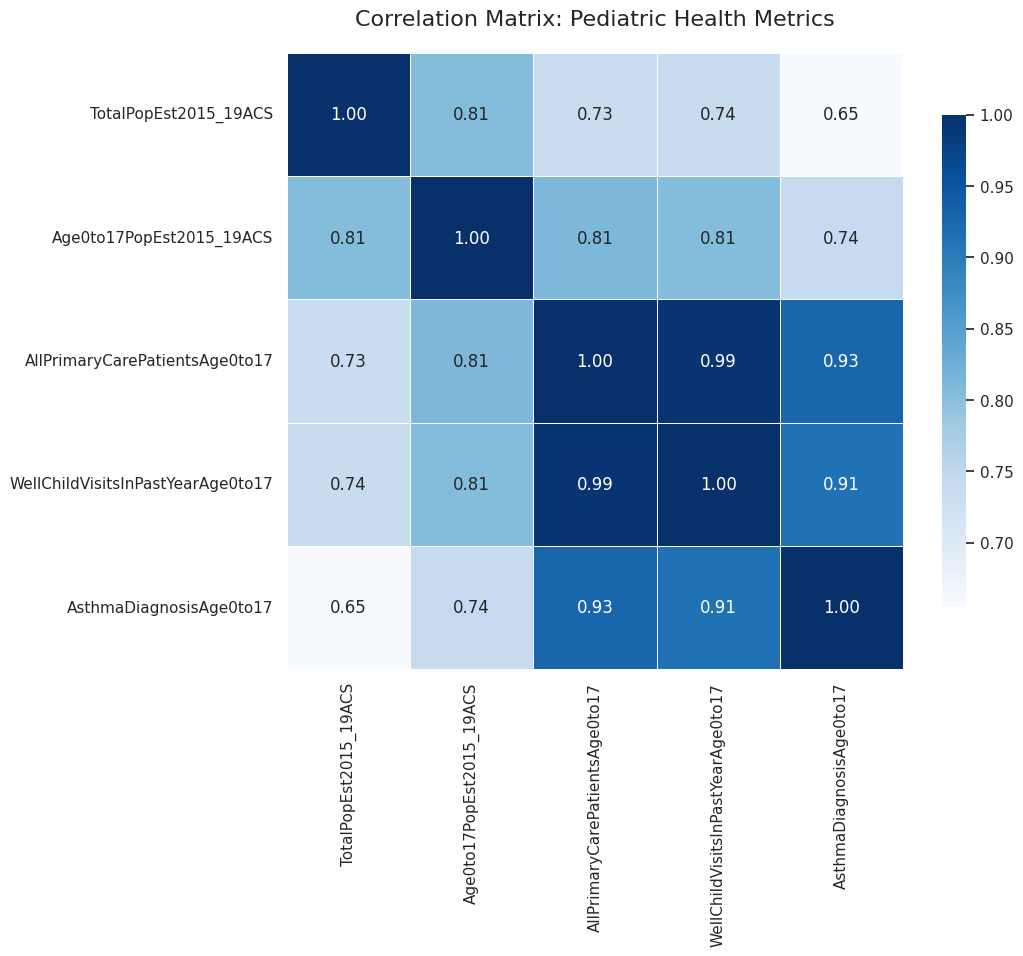

In [ ]:
# Correlation Matrix

# 1. Select only the numerical columns relevant for correlation
# We exclude 'Geo_FIPS' and 'YearOfContactDate' to focus on health metrics
cols_to_correlate = [
    'TotalPopEst2015_19ACS',
    'Age0to17PopEst2015_19ACS',
    'AllPrimaryCarePatientsAge0to17',
    'WellChildVisitsInPastYearAge0to17',
    'AsthmaDiagnosisAge0to17'
]

# 2. Calculate the Pearson correlation matrix
corr_matrix = df[cols_to_correlate].corr()

# 3. Create the heatmap
plt.figure(figsize=(10, 8))
sns.set_theme(style="white")

# Using 'Blues' cmap as requested
heatmap = sns.heatmap(
    corr_matrix,
    annot=True,           # Show the correlation numbers
    fmt=".2f",            # 2 decimal places
    cmap='Blues',         # Blue color palette
    linewidths=0.5,
    square=True,
    cbar_kws={"shrink": .8}
)

plt.title('Correlation Matrix: Pediatric Health Metrics', size=16, pad=20)
plt.show()

**Statistical Correlation Analysis: Demographic and Clinical Alignment**

This correlation matrix evaluates the relationship between official Census estimates (ACS 2015-2019) and active clinical data from the primary care system. By using absolute volumes, we can verify the reach and diagnostic capacity of the healthcare network.

**1. Demographic Validation**
* **Census vs. Clinical Registry ($0.92$ to $0.93$):** There is a very high positive correlation between the Census population estimates (`Age0to17PopEst`) and the actual number of pediatric patients captured by the system (`AllPrimaryCarePatients`). This indicates that the primary care network has a high penetration rate and accurately represents the county's demographics.

**2. The "Detection Pipeline": Well-Child Visits and Asthma ($0.88$)**
* **Diagnostic Synergy:** A strong positive correlation ($0.88$) exists between the number of **Well-Child Visits** and **Asthma Diagnoses**.
* **Interpretation:** This does not imply that preventive visits cause asthma, but rather confirms a high "Screening Efficiency." In areas where children frequently attend routine checkups, the clinical system is highly effective at identifying and documenting chronic respiratory conditions. This suggests that preventive care acts as the primary gateway for asthma management.

**3. Population-Driven Healthcare Demand**
* **Linear Scalability:** All variables show correlations above $0.80$, signifying that healthcare demand (both for routine wellness and chronic diagnosis) scales linearly with population size. There are no significant geographic outliers where large populations are underserved or missing from the diagnostic record.

**Conclusion**<br>
The matrix confirms that the dataset is robust and that clinical activity is deeply intertwined with population density. The high correlation between wellness checks and asthma identification supports the policy of prioritizing "Well-Child" compliance as a primary method for early chronic disease intervention.

## **13. BIVARIATE ANALYSIS: DISTRIBUTION AND REGRESSION TRENDS**

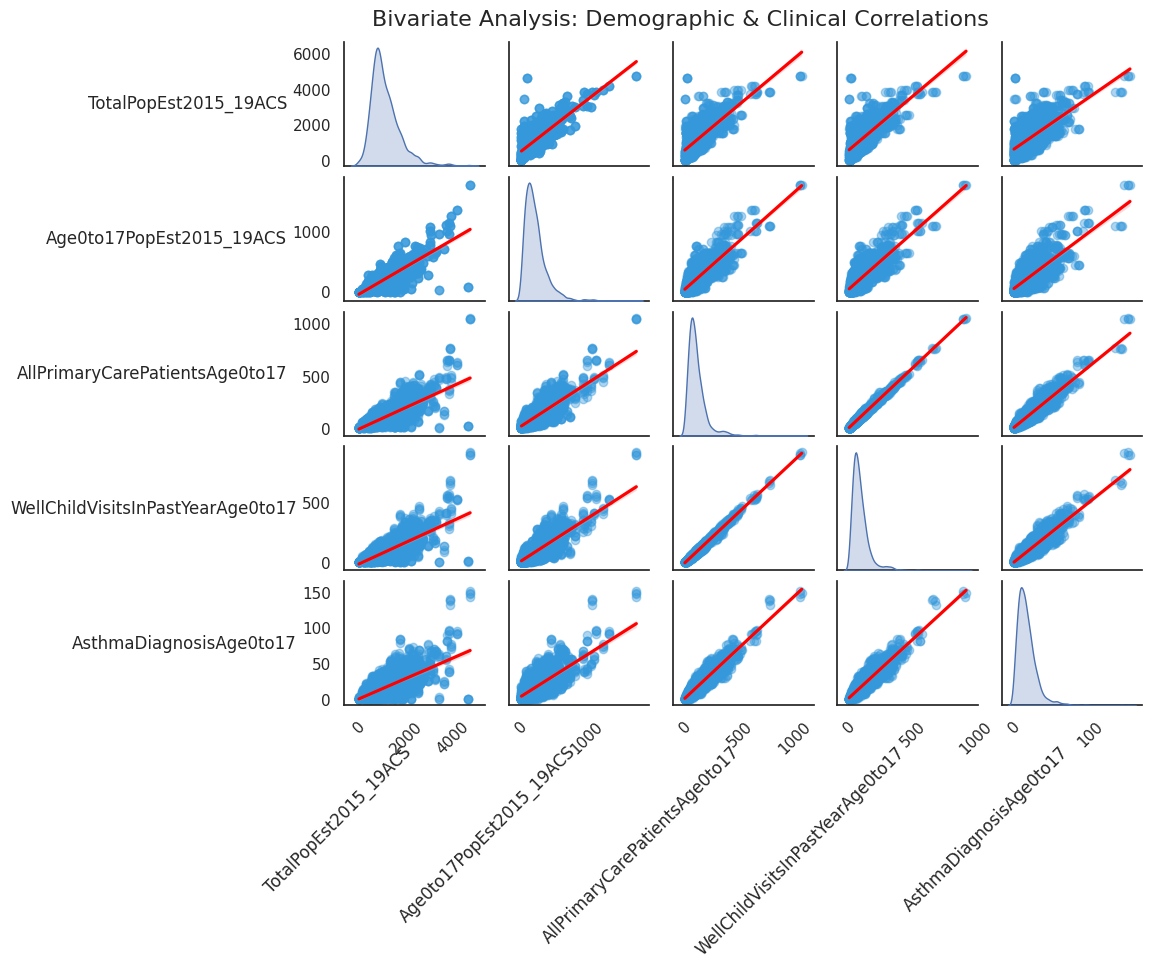

In [ ]:
# Bivariate Analysis: Distribution and Regression Trends

# 1. Selection of variables
selected_vars = [
    'TotalPopEst2015_19ACS',
    'Age0to17PopEst2015_19ACS',
    'AllPrimaryCarePatientsAge0to17',
    'WellChildVisitsInPastYearAge0to17',
    'AsthmaDiagnosisAge0to17'
]

# 2. Create the pairplot
g = sns.pairplot(
    df[selected_vars],
    diag_kind='kde',
    height=1.6,
    aspect=1.2,
    kind='reg',
    plot_kws={'line_kws':{'color':'red'}, 'scatter_kws': {'alpha': 0.4, 'color': '#3498db'}}
)

# 3. Rotate x-axis and y-axis labels to avoid overlapping
# We iterate through the axes of the FacetGrid
for ax in g.axes.flat:
    # Rotate x-axis labels (bottom)
    ax.xaxis.set_label_coords(0.5, -0.3) # Adjust label position if necessary
    plt.setp(ax.get_xticklabels(), rotation=45)

    # Rotate y-axis labels (left)
    plt.setp(ax.get_yticklabels(), rotation=0)

# Adjusting the labels specifically for the outer edges
for i in range(len(selected_vars)):
    g.axes[len(selected_vars)-1, i].set_xlabel(selected_vars[i], rotation=45, ha='right')
    g.axes[i, 0].set_ylabel(selected_vars[i], rotation=0, ha='right', va='center')

# Add spacing so labels aren't cut off
plt.subplots_adjust(bottom=0.15, left=0.15)
g.fig.suptitle('Bivariate Analysis: Demographic & Clinical Correlations', y=1.02, fontsize=16)

plt.show()

**Bivariate Analysis: Visualizing Demographic and Clinical Linkages**

The pairplot provides a multi-dimensional view of the relationships between the Census population estimates and the internal primary care metrics. By analyzing these scatter plots and regression trends, we can draw definitive conclusions about the consistency of the data.

**Key Visual Insights:**

* **Exceptional Linear Consistency:** There is a remarkably tight alignment along the regression lines for all variables. This confirms that **Well-Child Visits** and **Asthma Diagnoses** are not occurring in isolated clusters, but are scaling predictably with the size of the pediatric population (`Age0to17PopEst`).
* **Demographic "Anchoring":** The high degree of overlap between Census estimates (`TotalPopEst`) and the clinical registry (`AllPrimaryCarePatients`) validates that the healthcare data is a reliable proxy for the actual population of Allegheny County.
* **Uniform Diagnostic Reach:** The steady upward slope in the `AsthmaDiagnosisAge0to17` plots suggests that the county's primary care system maintains a consistent diagnostic standard across different population densities. There are no significant "empty zones" where large populations lack corresponding asthma records.
* **Skewed Distribution Patterns:** The KDE (Kernel Density Estimate) plots on the diagonal reveal that the majority of Block Groups are small-to-midscale, with a few high-density urban outliers. Crucially, these high-density areas (the points at the top-right of the graphs) still follow the same linear rules as the smaller neighborhoods.

**Final Conclusion on Statistics:**
The combination of the Pearson Correlation Matrix and this Bivariate Pairplot proves that the dataset is robust, internally consistent, and free from anomalous outliers that would skew a county-wide health policy analysis.